# vcut_viz.ipynb

In [1]:
import pandas as pd
import sqlite3
from icecream import ic
from shapely.geometry import Polygon
from graphviz import Digraph
import graphviz


In [2]:
sql = ''' 
SELECT *
FROM images, detections, vcuts
WHERE
    images.image_id=1 AND
	images.image_id=detections.image_id AND
	detections.detection_id=vcuts.detection_id
'''
df = pd.read_sql(sql, sqlite3.Connection('../test.db'))

for r in df.itertuples():
    coords = [(r.start_x, r.start_y), (r.far_x, r.far_y), (r.end_x, r.end_y)]
    triangle = Polygon(coords)
    centroid = triangle.centroid
    print(f'{r.image_id=}  {r.detection_id=}  {r.vcut_id=}  {centroid=}')

r.image_id=1  r.detection_id=1  r.vcut_id=1  centroid=<POINT (483.333 687.333)>
r.image_id=1  r.detection_id=1  r.vcut_id=2  centroid=<POINT (478 797)>
r.image_id=1  r.detection_id=1  r.vcut_id=3  centroid=<POINT (488.667 897.667)>
r.image_id=1  r.detection_id=1  r.vcut_id=4  centroid=<POINT (572.333 893)>
r.image_id=1  r.detection_id=1  r.vcut_id=5  centroid=<POINT (579.667 847)>
r.image_id=1  r.detection_id=1  r.vcut_id=6  centroid=<POINT (563.333 809.333)>
r.image_id=1  r.detection_id=1  r.vcut_id=7  centroid=<POINT (520.333 733.333)>
r.image_id=1  r.detection_id=2  r.vcut_id=8  centroid=<POINT (1055.667 1406.333)>
r.image_id=1  r.detection_id=2  r.vcut_id=9  centroid=<POINT (1044.333 1282.667)>
r.image_id=1  r.detection_id=2  r.vcut_id=10  centroid=<POINT (900.667 1367.667)>
r.image_id=1  r.detection_id=2  r.vcut_id=11  centroid=<POINT (755.333 1365)>
r.image_id=1  r.detection_id=2  r.vcut_id=12  centroid=<POINT (737 1373)>
r.image_id=1  r.detection_id=2  r.vcut_id=13  centroid=<PO

In [3]:
def draw_sqlite_schema(db_path):
    dot = Digraph(comment='Database Schema', graph_attr={'rankdir':'RL'})
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get all table names
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [t[0] for t in cursor.fetchall() if t[0] != 'sqlite_sequence']
    
    for table in tables:
    
        # Get column details
        cursor.execute(f"PRAGMA table_info({table})")
        columns = cursor.fetchall()
        
        # Build an HTML-like label for the table node
        label = f'<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0"><TR><TD COLSPAN="2"><B>{table}</B></TD></TR>'
        for col in columns:
            label += f'<TR><TD ALIGN="LEFT">{col[1]}</TD><TD ALIGN="LEFT">{col[2]}</TD></TR>'
        label += '</TABLE>>'
        
        dot.node(table, label=label, shape='none')
        
        # Check for Foreign Keys to draw relationships
        cursor.execute(f"PRAGMA foreign_key_list({table})")
        for fk in cursor.fetchall():
            dot.edge(table, fk[2], label='FK')
            
    conn.close()
    return dot

# Usage
# draw_sqlite_schema('../test.db')


# Database

This project uses a SQLite database for persistent storage of data extracted from images.
The database contains three tables: `images`, `detections` and `vcuts`. 

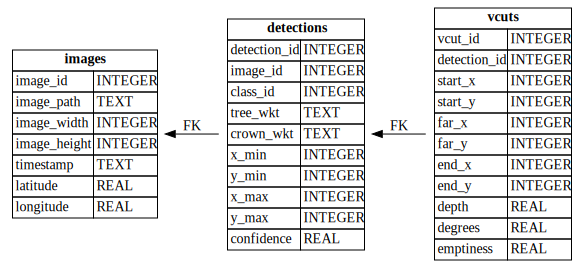

In [4]:
draw_sqlite_schema('../test.db')

## Images table

Each record in the `images` contains data for an image.

`timestamp`, `latitude` and `longitude` are extracted from EXIF metadata embedded in the image, when available.

I am considering storing `latitude` and `longitude` as WKT.

field | description
----- | -----------
image_id | image serial number
image_path | image file location
image_width | width of image in pixels
image_height | image height in pixels
timestamp | date and time when the image was recorded
latitude | location of the camera when the image was recorded; in decimal degrees
longitude | location of the camera when the image was recorded; in decimal degrees

## Detections table

Each record in the `detections` contains data for a 'coconut palm tree' detected by the SAM3 model.

I am considering removing the bounding box coordinates because they can be easily calculated from `tree_wkt`.

field | description
----- | -----------
detection_id | detection serial number
image_id | a foreign key linking the `detection` record to an `image` record
class_id | currently there is only one class (0 = 'coconut palm tree')
tree_wkt | a polygon surrounding the detected tree
crown _wkt | a polygon surrounding the crown of the detected tree
xmin | detection bounding box in pixels
ymin | detection bounding box in pixels
xmax | detection bounding box in pixels
ymax | detection bounding box in pixels
confidence | confidence level for the detection provided by the SAM3 object detector

## Vcuts table

Each record in the `vcuts` contains data for a v-shaped cut in the crown of a coconut palm detected as a convexity defect.

I am considering storing the 3 coordinates for the convexity defect as `triangle_wkt`.

field | description
----- | -----------
vcut_id | vcut serial number
detection_id | a foreign key linking the `vcut` record to a `detection` record
start_x | coordinates for convexity defect in pixels
start_y | coordinates for convexity defect in pixels
far_x | coordinates for convexity defect in pixels
far_y | coordinates for convexity defect in pixels
end_x | coordinates for convexity defect in pixels
end_y | coordinates for convexity defect in pixels
depth | distance from the 'far' point to the convex hull in pixels
degrees | angle of the vcut in degrees
emptiness | proportion of the vcut unoccupied by foliage

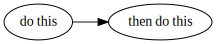

In [6]:
dot = '''
digraph {
    rankdir=LR
    a[label="do this"]
    b[label="then do this"]
    a -> b
}
'''
graphviz.Source(dot)